In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = [r"KI/NaCl", r"GaP_GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
dft_paths = [f"dft_results/{system}.csv" for system in systems]
# Column names
energy_col = "relaxed_energy"
conv_col = "convergence_steps"
# Plotting configuration
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})
fig_width = 7.2
fig_height = 2.4
fig_layout = dict(
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05,
    wspace=0.3,
)
panel_label_size = 14
violin_colors = ["#3D546F", "#2F5D9B", "#9FB6D9"]
# Sampling parameters
top_k = 8
n_samples = 10000
seed = 0

In [190]:
def compute_sampling_distributin(energy, steps, top_k, n_samples, seed):
    rng = np.random.default_rng(seed)
    e_ref = np.median(energy[:top_k])
    s_ref = np.median(steps[:top_k])
    rel_e = np.empty(n_samples)
    rel_s = np.empty(n_samples)
    n = len(energy)

    for i in range(n_samples):
        idx = rng.choice(n, top_k, replace=False)
        rel_e[i] = np.median(energy[idx]) - e_ref
        rel_s[i] = np.median(steps[idx]) - s_ref

    # IQR scaling
    iqr_e = np.percentile(rel_e, 75) - np.percentile(rel_e, 25)
    iqr_s = np.percentile(rel_s, 75) - np.percentile(rel_s, 25)

    if iqr_e > 0:
        rel_e /= iqr_e
    else:
        rel_e = np.zeros_like(rel_e)

    if iqr_s > 0:
        rel_s /= iqr_s
    else:
        rel_s = np.zeros_like(rel_s)

    return rel_e, rel_s

In [191]:
data_store = []
es = []
ss = []

for system, title, path in zip(systems, titles, dft_paths):
    df = pd.read_csv(path).copy()
    energy = df[energy_col].to_numpy(dtype=float)
    steps = df[conv_col].to_numpy(dtype=float)
    data_store.append((title, energy, steps))

for i, (title, energy, steps) in enumerate(data_store):
    rel_e, rel_s = compute_sampling_distributin(energy, steps, top_k, n_samples, seed)
    es.append(rel_e)
    ss.append(rel_s)

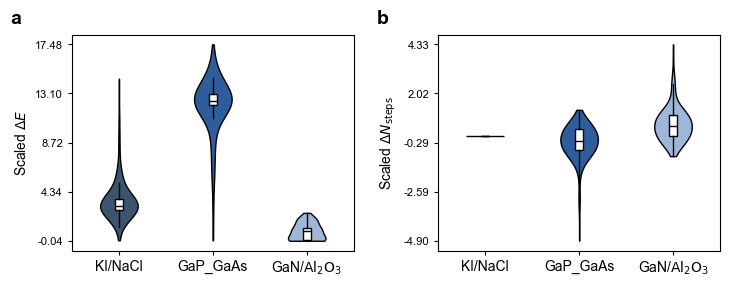

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))
data_list = [es, ss]
ylabels = [r"Scaled $\Delta E$", r"Scaled $\Delta N_{\mathrm{steps}}$"]
panel_labels = ["a", "b"]

for i, ax in enumerate(axes):
    data = data_list[i]
    pos = np.arange(len(data))
    vp = ax.violinplot(data, positions=pos, widths=0.4, bw_method=0.6, points=400, showextrema=False)
    for b, c in zip(vp["bodies"], violin_colors):
        b.set_facecolor(c)
        b.set_edgecolor("#000000")
        b.set_linewidth(1.0)
        b.set_alpha(1.0)
    bp = ax.boxplot(
        data,
        positions=pos,
        widths=0.08,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#FFFFFF", edgecolor="#000000", linewidth=1.0),
        medianprops=dict(color="#000000", linewidth=1.0),
        whiskerprops=dict(color="#000000", linewidth=1.0),
        capprops=dict(linewidth=0),
    )
    ax.set_xticks(pos)
    ax.set_xticklabels(titles)
    ax.set_ylabel(ylabels[i])
    ax.tick_params(direction="out", length=3, width=0.8)
    ax.text(-0.22, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=panel_label_size, fontweight="bold")
    all_vals = np.concatenate(data)
    ymin, ymax = np.min(all_vals), np.max(all_vals)
    yticks = np.linspace(ymin, ymax, 5)
    ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

plt.subplots_adjust(**fig_layout)
plt.savefig("screening_performance.pdf", bbox_inches="tight")
plt.show()
